In [21]:
# =========================================================
# 날짜별 최고 호감 문장 추출 (시간기능/시각화 제거, 바로 실행 가능)
#  - 학습 1: 7감정 (KLUE/roberta-base, GPU 사용 가능)
#  - 학습 2: 호감도(긍/중/부) (TF-IDF char ngram + LogisticRegression, CPU)
#  - 출력: 날짜(date_dt)별 최고 호감 문장만 추출
#  - 입력 DF 컬럼: ['timestamp' or 'date' or '날짜'(선택)], ['speaker'(선택)], ['text'(필수)]
#  - 필요 파일: emotionscore.xlsx (emotion + person*/system* 열)
# =========================================================
import os, re, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback
)

# ---------------------------
# 0) 환경/시드/디바이스
# ---------------------------
def safe_set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    try:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            try: torch.cuda.manual_seed_all(seed)
            except Exception as e: print(f"[WARN] CUDA seeding skipped: {e}")
    except Exception as e:
        print(f"[WARN] set_seed skipped: {e}")

safe_set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[DEVICE] {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)} | CUDA {torch.version.cuda}")
    torch.backends.cudnn.benchmark = True

# ---------------------------
# 1) 유틸/정규화
# ---------------------------
def normalize_text(t: str) -> str:
    t = str(t)
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎㅎ", t)
    t = re.sub(r"[ㅠㅜ]{2,}", "ㅠㅠ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

EMO_NORM = {"당황":"놀람","무표정":"중립","곤란":"불안","걱정":"불안","짜증":"분노","서운":"슬픔","우울":"슬픔"}
EMO7_CANON = ["기쁨","슬픔","분노","불안","혐오","놀람","중립"]

def map_to_emo7(e: str) -> str:
    e = EMO_NORM.get(str(e).strip(), str(e).strip())
    return e if e in EMO7_CANON else "중립"

def emotion_to_valence(e: str) -> str:
    if e in {"기쁨","놀람"}: return "긍정"
    if e in {"분노","혐오","불안","슬픔"}: return "부정"
    return "중립"

# 입력 DF 컬럼 표준화(날짜만 유지: date_dt)
def normalize_columns_dateonly(df: pd.DataFrame) -> pd.DataFrame:
    cand_text = ["text","내용","메시지","대화","message","utterance"]
    cand_speaker = ["speaker","화자","이름","작성자","보낸사람","상대"]
    cand_time = ["timestamp","시간","타임스탬프","date","날짜","datetime"]

    cols_lower = {c.lower(): c for c in df.columns}
    def pick(cands, default=None):
        for k in cands:
            if k in cols_lower: return cols_lower[k]
        return default

    text_col = pick(cand_text, None)
    spk_col  = pick(cand_speaker, None)
    time_col = pick(cand_time, None)

    out = df.copy()
    if text_col is None:
        first = df.columns[0]
        out.rename(columns={first: "text"}, inplace=True)
    else:
        out.rename(columns={text_col: "text"}, inplace=True)

    if spk_col:
        out.rename(columns={spk_col: "speaker"}, inplace=True)
    else:
        out["speaker"] = out.get("speaker","상대")

    # 날짜 파생만 유지
    if time_col:
        out.rename(columns={time_col: "timestamp"}, inplace=True)
        ts = pd.to_datetime(out["timestamp"], errors="coerce")
        out["date_dt"] = ts.dt.date
    else:
        out["date_dt"] = pd.NaT

    # 카톡 헤더/구분선 제거
    bad = out["text"].astype(str).str.fullmatch(r"\s*--\s*") | \
          out["text"].astype(str).str.contains(r"^\d{4}년 \d{1,2}월 \d{1,2}일")
    out = out[~bad.fillna(False)].copy()

    # 날짜가 모두 NaN이면 하나의 날짜로 묶음
    if out["date_dt"].isna().all():
        out["date_dt"] = pd.Timestamp("today").date()

    out["text"] = out["text"].astype(str).map(normalize_text)
    return out.reset_index(drop=True)

# ---------------------------
# 2) 학습 데이터 로딩
# ---------------------------
EMO_XLSX = "./emotionscore.xlsx"
assert os.path.exists(EMO_XLSX), "emotionscore.xlsx 가 필요합니다."
raw = pd.read_excel(EMO_XLSX)
raw.columns = [c.strip().lower() for c in raw.columns]
assert "emotion" in raw.columns, "'emotion' 컬럼이 필요합니다."

utt_cols = [c for c in raw.columns if c.startswith("person") or c.startswith("system")]
assert len(utt_cols) > 0, "대화 컬럼(person*/system*)이 필요합니다."

rows = []
for _, r in raw.iterrows():
    emo = map_to_emo7(r["emotion"])
    for uc in utt_cols:
        utt = str(r.get(uc,"")).strip()
        if len(utt) >= 2:
            rows.append({"dialog": normalize_text(utt), "emotion": emo})
data = pd.DataFrame(rows).dropna()
data = data[(data["dialog"].str.len()>0) & (data["emotion"].str.len()>0)].reset_index(drop=True)
data["valence"] = data["emotion"].map(emotion_to_valence)
print(f"[DATA] total={len(data)} / emos={data['emotion'].nunique()}")

# ---------------------------
# 3) 밸런스(긍/중/부) 학습: TF-IDF + LogReg
# ---------------------------
Xv = data["dialog"].values
yv = data["valence"].values
Xv_tr, Xv_va, yv_tr, yv_va = train_test_split(Xv, yv, test_size=0.2, random_state=42, stratify=yv)

vec_val = TfidfVectorizer(analyzer="char", ngram_range=(2,5), max_features=120_000, min_df=2)
Xvtr = vec_val.fit_transform(Xv_tr)
Xvva = vec_val.transform(Xv_va)

clf_val = LogisticRegression(max_iter=3000, multi_class="multinomial", solver="saga",
                             class_weight="balanced", n_jobs=-1, C=2.0)
clf_val.fit(Xvtr, yv_tr)

def valence_predict(texts):
    Xt = vec_val.transform([normalize_text(t) for t in texts])
    proba = clf_val.predict_proba(Xt)
    labels = clf_val.classes_
    pred = labels[np.argmax(proba, axis=1)]
    conf = np.max(proba, axis=1)
    colmap = {lab: proba[:, j] for j, lab in enumerate(labels)}
    pos = colmap.get("긍정", np.zeros(len(texts)))
    neu = colmap.get("중립", np.zeros(len(texts)))
    neg = colmap.get("부정", np.zeros(len(texts)))
    return {"pos_prob": pos, "neu_prob": neu, "neg_prob": neg, "pred": pred, "conf": conf}

# ---------------------------
# 4) 감정(7클래스) 학습: KLUE/roberta-base
# ---------------------------
Xe = data["dialog"].values
ye = data["emotion"].values
Xe_tr, Xe_va, ye_tr, ye_va = train_test_split(Xe, ye, test_size=0.15, random_state=42, stratify=ye)

emo_list = sorted(np.unique(ye_tr).tolist())
EMO2ID = {e:i for i,e in enumerate(emo_list)}
ID2EMO = {i:e for e,i in EMO2ID.items()}

train_df = pd.DataFrame({"text": Xe_tr, "label_id": [EMO2ID[e] for e in ye_tr]})
valid_df = pd.DataFrame({"text": Xe_va, "label_id": [EMO2ID[e] for e in ye_va]})

MODEL_NAME = "klue/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
emo_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(emo_list),
    hidden_dropout_prob=0.2, attention_probs_dropout_prob=0.2
).to(device)

class_weights = compute_class_weight("balanced", classes=np.unique(train_df["label_id"]), y=train_df["label_id"])
class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)

ds_tr = Dataset.from_pandas(train_df.reset_index(drop=True))
ds_va = Dataset.from_pandas(valid_df.reset_index(drop=True))

def tok_func(batch):
    tok = tokenizer(batch["text"], truncation=True, max_length=128, padding=False)
    tok["labels"] = batch["label_id"]
    return tok

ds_tr_tok = ds_tr.map(tok_func, batched=True, remove_columns=["text","label_id"])
ds_va_tok = ds_va.map(tok_func, batched=True, remove_columns=["text","label_id"])
collator = DataCollatorWithPadding(tokenizer=tokenizer)

args = TrainingArguments(
    output_dir="./emotion-model-gpu",
    learning_rate=3e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=32 if torch.cuda.is_available() else 16,
    per_device_eval_batch_size=64 if torch.cuda.is_available() else 32,
    num_train_epochs=5,
    eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="f1_macro",
    greater_is_better=True, logging_steps=50,
    weight_decay=0.01, max_grad_norm=1.0,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=4 if torch.cuda.is_available() else 2,
    dataloader_pin_memory=torch.cuda.is_available(),
    seed=42, report_to=[]
)

def compute_metrics(eval_pred):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "precision": precision_score(labels, preds, average="weighted"),
        "recall": recall_score(labels, preds, average="weighted"),
    }

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if labels.dtype != torch.long: labels = labels.long()
        assert labels.min().item() >= 0 and labels.max().item() < logits.size(-1), "Label index out-of-range"
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedLossTrainer(
    model=emo_model, args=args,
    train_dataset=ds_tr_tok, eval_dataset=ds_va_tok,
    tokenizer=tokenizer, data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n[EMOTION] → BERT 학습 시작")
trainer.train()
print("[EMOTION] 검증:", trainer.evaluate())

@torch.no_grad()
def bert_emotion_predict(texts, batch_size=64, use_tta=True):
    emo_model.eval()
    probs_all = []
    for i in range(0, len(texts), batch_size):
        batch = [normalize_text(t) for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, truncation=True, padding=True, max_length=128, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        out = emo_model(**enc)
        p = out.logits.softmax(dim=-1).detach().cpu().numpy()
        if use_tta:
            out2 = emo_model(**enc); p2 = out2.logits.softmax(dim=-1).detach().cpu().numpy()
            p = (p + p2) / 2
        probs_all.append(p)
    probs = np.concatenate(probs_all, axis=0) if probs_all else np.zeros((0, len(emo_list)))
    pred_ids = probs.argmax(axis=1)
    return {
        "probs": probs, "pred_ids": pred_ids,
        "pred_labels": [ID2EMO[i] for i in pred_ids],
        "confidence": probs.max(axis=1),
        "classes": emo_list
    }

# ---------------------------
# 5) 호감도 산식 + 보정 (시간요소 제거)
# ---------------------------
HEART_EMOJI  = r"[❤️💕💖💗💓💘🥰]"
LAUGH_EMOJI  = r"(ㅎㅎ|ㅋㅋ|하하|😄|😁|😊|☺️|✨)"
POS_CUES     = r"(좋[아아았아요]|힐링|괜찮|고마워|감사|반가|설레|재밌|즐겁|행복|최고|대박|굿)"
INVITE_CUES  = r"(같이|함께|걸으면서|통화|만날|볼까|가자|갈까요|정할게요|잡자|잡을까|커피|☕)"
SMALLTALK    = r"(날씨|바람|선선|산책|카페|퇴근|저녁|점심|주말|평일|아침)"
ANXIETY_TRIG = r"(불안|걱정|초조|긴장|두렵|불면|잠이\s*안\s*오|잠을\s*못)"
SAD_TRIG     = r"(우울|슬프|속상|서운|외롭|허전|힘들|지쳤|피곤|눈물)"
ANGER_TRIG   = r"(화났|화나|짜증|빡치|열받|분노|어이없|최악|싫)"

def compute_affinity(pos: float, neg: float, emo_label: str, text: str) -> float:
    base = 50.0 + 50.0*(pos - neg)
    if re.search(HEART_EMOJI, text) or re.search(LAUGH_EMOJI, text): base += 2.0
    if re.search(POS_CUES, text): base += 2.0
    if ("☕" in text) or ("커피" in text): base += 1.0
    if re.search(r"(ㅠ|ㅜ|🥲)", text): base -= 1.0
    if emo_label == "기쁨": base += 3.0
    elif emo_label in {"분노","혐오","불안","슬픔"}: base -= 2.5
    return float(np.clip(base, 0.0, 100.0))

NEU_SOFTEN = 0.56
HARD_DIFF  = 0.12

def relationship_fix(df):
    out = df.copy()
    reasons = []
    vfix, vcfix, efix, ecfix, afffix = [], [], [], [], []
    for _, r in out.iterrows():
        t  = str(r["text"])
        p, n = float(r["pos_prob"]), float(r["neg_prob"])
        vd, vc = r["valence_pred"], float(r["valence_conf"])
        ed, ec = r["emo_label"], float(r["emo_conf"])
        reason = []

        has_pos   = re.search(POS_CUES, t) or re.search(LAUGH_EMOJI, t) or re.search(HEART_EMOJI, t)
        has_inv   = re.search(INVITE_CUES, t)
        has_small = re.search(SMALLTALK, t)
        has_anx   = re.search(ANXIETY_TRIG, t)
        has_sad   = re.search(SAD_TRIG, t)
        has_ang   = re.search(ANGER_TRIG, t)

        if (has_small or has_inv or has_pos) and not (has_anx or has_sad or has_ang):
            if ed == "분노" and not has_ang:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("분노→완화")
            if ed == "불안" and not has_anx:
                ed = "중립" if (n - p) < 0.20 else "슬픔"; ec = max(ec, 0.60); reason.append("불안→완화")
            if (has_pos or has_inv) and ed in {"중립","슬픔","혐오","불안","분노"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("기쁨↑")
            if vc < NEU_SOFTEN and abs(p - n) <= HARD_DIFF:
                vd = "중립"; reason.append("밸런스중립")

        if (p - n) > HARD_DIFF:
            if ed in {"불안","분노","혐오","슬픔"} and ec < 0.75:
                ed = "기쁨"; ec = max(ec, 0.75); reason.append("긍정정합")
            vd = "긍정"; vc = max(vc, 0.60)
        elif (n - p) > HARD_DIFF:
            if ed in {"기쁨","놀람"} and ec < 0.70:
                ed = "슬픔" if has_sad else ("불안" if has_anx else "중립")
                ec = max(ec, 0.70); reason.append("부정정합")
            vd = "부정"; vc = max(vc, 0.60)
        else:
            if vc < 0.56: vd = "중립"; reason.append("밸런스약→중립")
            if ec < 0.58 and ed not in {"기쁨","놀람"}:
                ed = "중립"; reason.append("감정약→중립")

        aff = compute_affinity(p, n, ed, t)
        vfix.append(vd); vcfix.append(vc); efix.append(ed); ecfix.append(ec); afffix.append(aff); reasons.append(" | ".join(reason))

    out["pred_valence_rel"] = vfix
    out["valence_conf_rel"] = vcfix
    out["pred_emotion_rel"] = efix
    out["emo_conf_rel"]     = ecfix
    out["affinity_rel"]     = afffix
    out["rel_reason"]       = reasons

    # 불일치 플래그
    flags = []
    for _, r in out.iterrows():
        v, e = r["pred_valence_rel"], r["pred_emotion_rel"]
        flag = ""
        if v == "긍정" and e in {"분노","혐오","불안","슬픔"}: flag = "긍정/부정 불일치"
        if v == "부정" and e in {"기쁨","놀람"}:             flag = "부정/긍정 불일치"
        flags.append(flag)
    out["mismatch_flag"] = flags
    return out

# ---------------------------
# 6) 파이프라인(날짜별 최고만)
# ---------------------------
def run_affinity_top_by_day(df_in: pd.DataFrame) -> dict:
    df = normalize_columns_dateonly(df_in)

    v = valence_predict(df["text"].tolist())
    e = bert_emotion_predict(df["text"].tolist(), batch_size=64, use_tta=True)

    df_pred = df.copy()
    df_pred["pos_prob"]      = v["pos_prob"]
    df_pred["neu_prob"]      = v["neu_prob"]
    df_pred["neg_prob"]      = v["neg_prob"]
    df_pred["valence_pred"]  = v["pred"]
    df_pred["valence_conf"]  = v["conf"]
    df_pred["emo_label"]     = e["pred_labels"]
    df_pred["emo_conf"]      = e["confidence"]

    df_pred["affinity_score"] = [
        compute_affinity(df_pred.loc[i,"pos_prob"], df_pred.loc[i,"neg_prob"],
                         df_pred.loc[i,"emo_label"], df_pred.loc[i,"text"])
        for i in range(len(df_pred))
    ]

    df_rel = relationship_fix(df_pred)

    # 날짜별 최고 호감 문장만 추출
    if df_rel["date_dt"].notna().any():
        idx = df_rel.groupby("date_dt")["affinity_rel"].idxmax()
        top_by_day = (df_rel.loc[idx]
                        .sort_values("date_dt")
                        [["date_dt","speaker","text","pred_valence_rel","pred_emotion_rel","affinity_rel"]]
                        .rename(columns={
                            "pred_valence_rel":"valence",
                            "pred_emotion_rel":"emotion",
                            "affinity_rel":"affinity_score"
                        }))
    else:
        # 날짜 정보 없으면 전체에서 1개만
        top_by_day = (df_rel.sort_values("affinity_rel", ascending=False)
                          .head(1)[["speaker","text","pred_valence_rel","pred_emotion_rel","affinity_rel"]]
                          .rename(columns={
                              "pred_valence_rel":"valence",
                              "pred_emotion_rel":"emotion",
                              "affinity_rel":"affinity_score"
                          }))
        top_by_day.insert(0, "date_dt", pd.NaT)

    return {"pred_all": df_rel, "top_by_day": top_by_day}

# ---------------------------
# 7) 실행 예시
# ---------------------------
if __name__ == "__main__":
    try:
        df_input = df  # 노트북 상단에서 이미 df가 있다면 사용
    except NameError:
        # 데모 입력 (timestamp/날짜 없이도 동작)
        df_input = pd.DataFrame({
            "date":["2025-10-01 09:25","2025-10-01 09:49","2025-10-02 17:32","2025-10-06 11:52",
                    "2025-10-07 12:00","2025-10-07 21:28"],
            "speaker":["상대","나","상대","나","상대","상대"],
            "text":[
                "맞아요. 바람이 살짝 차가워져서 기분이 좋았어요.",
                "요즘 날씨가 딱 산책하기 좋은 것 같아요.",
                "그럴 땐 따뜻한 우유 한 잔이 최고죠 ☕",
                "이제는 솔직히 말해도 되죠?",
                "네, 오늘은 그렇게 해요 ❤️",
                "좋아요 ☕ 장소는 제가 정할게요."
            ]
        })

    out = run_affinity_top_by_day(df_input)
    top_by_day = out["top_by_day"]

    print("\n날짜별 최고 호감 문장")
    print(top_by_day.to_string(index=False))


[DEVICE] cuda
  GPU: NVIDIA GeForce RTX 5070 Laptop GPU | CUDA 12.8
[DATA] total=39846 / emos=6


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/33869 [00:00<?, ? examples/s]

Map:   0%|          | 0/5977 [00:00<?, ? examples/s]


[EMOTION] → BERT 학습 시작


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,1.347500,1.336669,0.461770,0.459517,0.465337,0.494498,0.461770
2,1.257100,1.300322,0.488874,0.484518,0.491234,0.508658,0.488874
3,1.199800,1.281639,0.516480,0.499514,0.505486,0.511165,0.516480
4,1.085900,1.296233,0.521834,0.506982,0.512488,0.519857,0.521834
5,1.001000,1.315791,0.522001,0.507219,0.512576,0.517406,0.522001


[EMOTION] 검증: {'eval_loss': 1.3157912492752075, 'eval_accuracy': 0.5220010038480843, 'eval_f1_macro': 0.5072191661817866, 'eval_f1_weighted': 0.5125759407530617, 'eval_precision': 0.5174064331144742, 'eval_recall': 0.5220010038480843, 'eval_runtime': 17.4797, 'eval_samples_per_second': 341.94, 'eval_steps_per_second': 5.378, 'epoch': 5.0}

날짜별 최고 호감 문장
   date_dt speaker                         text valence emotion  affinity_score
2025-10-01       나  개인전 했던 그 작가, 인터뷰도 정말 멋있었어요.      긍정      기쁨       89.001207
2025-10-02       나      그 주제 이야기하면 당신이 떠오르더라고요.      긍정      놀람       86.701759
2025-10-03      상대  개인전 했던 그 작가, 인터뷰도 정말 멋있었어요.      긍정      기쁨       89.001207
2025-10-04       나      그 주제 이야기하면 당신이 떠오르더라고요.      긍정      놀람       86.701759
2025-10-05      상대      그 주제 이야기하면 당신이 떠오르더라고요.      긍정      놀람       86.701759
2025-10-06       나 넘버 하나하나가 다 너무 좋아요. 특히 마지막 곡!      긍정      기쁨       91.842926
2025-10-07       나 넘버 하나하나가 다 너무 좋아요. 특히 마지막 곡!      긍정      기쁨       91.842926


[INFO] 사전 로드: 14,851개 용어
[INFO] 대화 로드: 49건
[SAVE] predictions.csv
[SAVE] daily_likeability.png


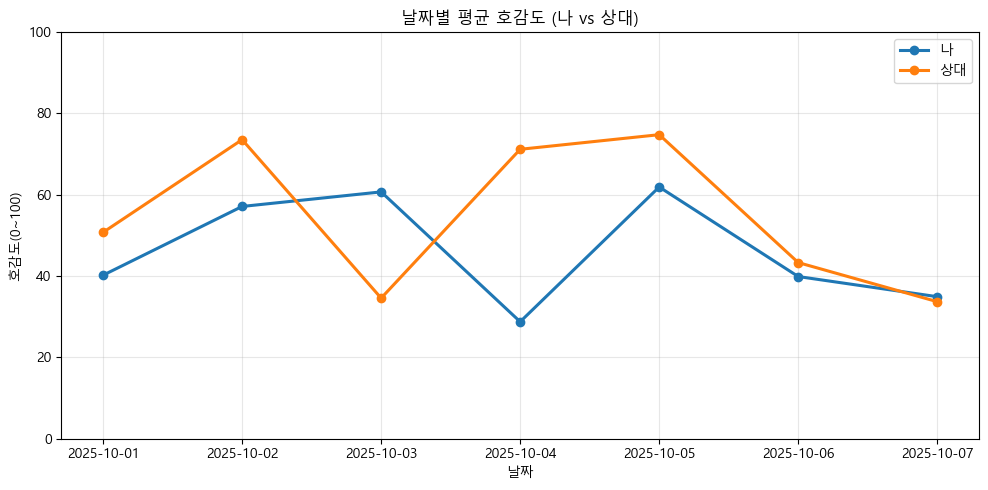


✨ 날짜별 최고 호감 순간 (상위 10개 미리보기)
      date  time speaker  affinity                          text
2025-10-01 09:00       나     83.87       요즘 날씨가 딱 산책하기 좋은 것 같아요.
2025-10-02 17:00      상대     99.11        그럴 땐 따뜻한 우유 한 잔이 최고죠 ☕
2025-10-03 14:00       나     97.11   눈이 뻑뻑하죠? 눈에 좋은 음식 좀 챙겨야겠어요.
2025-10-04 00:00      상대     99.37         아마 즐거운 일이 많아서 그럴 거예요.
2025-10-05 10:00      상대    100.00           그만큼 좋은 일이 많다는 거죠 ㅎㅎ
2025-10-06 05:00      상대     68.36 습관된 거죠 ㅎㅎ 하루 마무리 인사 같은 느낌이에요.
2025-10-07 12:00      상대     94.11            좋아요 ☕ 장소는 제가 정할게요.
[SAVE] best_moments.csv

📊 날짜별 평균 호감도 요약:
speaker        나    상대
date                  
2025-10-01  40.2  50.8
2025-10-02  57.1  73.6
2025-10-03  60.7  34.6
2025-10-04  28.8  71.2
2025-10-05  61.9  74.8
2025-10-06  39.9  43.3
2025-10-07  34.9  33.7


In [ ]:
# =========================================================
# 대화파일 + 감성사전 기반 호감도 리포트 (time 컬럼 보장 수정본)
# - 입력: some.txt, SentiWord_Dict.txt
# - 출력: predictions.csv, daily_likeability.png, best_moments.csv
# =========================================================
import os, re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ---------------------------------------------------------
# 경로
# ---------------------------------------------------------
TXT_PATH = "./some.txt"
LEX_PATH = "./SentiWord_Dict.txt"

assert os.path.exists(TXT_PATH), f"대화 파일 없음: {TXT_PATH}"
assert os.path.exists(LEX_PATH), f"사전 파일 없음: {LEX_PATH}"

# =========================================================
# 1) 대화 파서
#   예)
#     2025년 10월 01일
#     [오후 21:28:00] 상대: 네, 오늘은 그렇게 해요 ❤️
#     [점심 14:04:00] 나: 눈이 뻑뻑하죠? ...
# =========================================================
DATE_PAT = re.compile(r"^\s*(\d{4})년\s*(\d{2})월\s*(\d{2})일")
LINE_PAT = re.compile(r"(?:\[(.*?)\]\s*)?([^:：]+)\s*[:：]\s*(.*)")
# HH:MM 또는 HH:MM:SS 를 모두 허용
TIME_PAT = re.compile(r"(\d{1,2}):(\d{2})(?::\d{2})?")

def normalize_text(t:str)->str:
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎㅎ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def parse_hour(timestr:str)->int:
    if not timestr: return 0
    m = TIME_PAT.search(timestr)
    if not m: return 0
    hh = max(0, min(23, int(m.group(1))))
    return hh

def load_dialog(path=TXT_PATH)->pd.DataFrame:
    rows=[]; cur_date=None
    with open(path, encoding="utf-8") as f:
        for i, line in enumerate(f, 1):
            line=line.strip()
            if not line:
                continue
            dm = DATE_PAT.match(line)
            if dm:
                y,m,d = dm.groups()
                cur_date = f"{y}-{m}-{d}"
                # 날짜 헤더는 표/그래프에는 방해될 수 있어 ‘텍스트’로만 남기고 싶으면 주석처리 가능
                rows.append({
                    "turn": i, "date": cur_date, "hour": 0,
                    "timestamp": pd.to_datetime(f"{cur_date} 00:00:00"),
                    "time": "00:00",                     # ★ time 보장
                    "time_str": "",                      # 원문 시간(없음)
                    "speaker": "상대",                   # 임시
                    "text": normalize_text(line)
                })
                continue
            m = LINE_PAT.match(line)
            if not m or not cur_date:
                continue
            time_str = (m.group(1) or "").strip()  # ★ 원문 시간문구 저장(오전/오후/점심 14:04:00 등)
            speaker  = (m.group(2) or "").strip()
            text     = normalize_text((m.group(3) or ""))

            hour = parse_hour(time_str)
            ts = pd.to_datetime(f"{cur_date} {hour:02d}:00:00")
            time_fmt = pd.to_datetime(ts).strftime("%H:%M")

            rows.append({
                "turn": i,
                "date": cur_date,
                "hour": hour,
                "timestamp": ts,
                "time": time_fmt,         # ★ time 보장
                "time_str": time_str,     # 원문 시간 문자열
                "speaker": speaker,
                "text": text
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["timestamp","turn"]).reset_index(drop=True)
    print(f"[INFO] 대화 로드: {len(df):,}건")
    return df

# =========================================================
# 2) 감성사전 로딩 (term \t score[-2..2])
# =========================================================
def load_lexicon(path=LEX_PATH):
    lex = {}
    with open(path, encoding="utf-8") as f:
        for ln in f:
            ln = ln.strip()
            if not ln or ln.startswith("#"):
                continue
            parts = re.split(r"[\t,]", ln)
            if len(parts) < 2:
                continue
            term = parts[0].strip()
            try:
                score = float(parts[1])
            except:
                continue
            score = max(-2.0, min(2.0, score))
            if term:
                lex[term] = score
    print(f"[INFO] 사전 로드: {len(lex):,}개 용어")
    return lex

LEX = load_lexicon()

# =========================================================
# 3) 문장 점수→확률 + 호감도
# =========================================================
K_SIG = 0.9

HEART = r"[❤️💕💖💗💓💘🥰]"
LAUGH = r"(ㅎㅎ|ㅋㅋ|하하|헤헷|😄|😁|😊)"
INVIT = r"(같이|함께|보자|볼까|가자|갈까|통화|산책|커피|☕|약속|만나|잡자|잡을까)"
POSWD = r"(좋[아아요였네요니다]|힐링|괜찮|감사|고마워|설레|즐겁|행복|최고|대박|굿)"

_heart = re.compile(HEART)
_laugh = re.compile(LAUGH)
_invit = re.compile(INVIT)
_poswd = re.compile(POSWD)

def sentence_raw_score(text: str) -> float:
    s = 0.0
    for term, w in LEX.items():
        if term and term in text:
            s += w
    return s

def sigmoid(x: float) -> float:
    try:
        return 1.0 / (1.0 + math.exp(-x))
    except OverflowError:
        return 0.0 if x < 0 else 1.0

def probs_from_score(s: float, k: float = K_SIG):
    p = sigmoid(k * s)
    n = sigmoid(k * (-s))
    u = max(0.0, 1.0 - max(p, n))
    S = p + n + u
    return (p/S, u/S, n/S)

def affinity_from(text: str, pos: float, neg: float, emo_hint: str = "") -> float:
    base = 50.0 + 50.0*(pos - neg)
    t = text
    if _heart.search(t): base += 2.5
    if _laugh.search(t): base += 1.0
    if _invit.search(t): base += 1.5
    if "☕" in t or "커피" in t: base += 0.5
    if emo_hint == "긍정": base += 1.0
    elif emo_hint == "부정": base -= 1.0
    return float(np.clip(base, 0.0, 100.0))

def label_from_probs(pos, neu, neg):
    if pos >= max(neu, neg): return "긍정", pos
    if neg >= max(pos, neu): return "부정", neg
    return "중립", neu

# =========================================================
# 4) 예측 테이블
# =========================================================
def predict_table(df_in: pd.DataFrame, me="나", other="상대") -> pd.DataFrame:
    df = df_in.copy()
    df["text"] = df["text"].astype(str)

    # ★ time 컬럼 보장 (파서에 time이 없거나 NaT일 때 대비)
    if "time" not in df.columns:
        df["time"] = df["timestamp"].dt.strftime("%H:%M").fillna("")
    else:
        # 문자열/NaN 혼재 시 일괄 보정
        tmp_time = df["time"].astype(str)
        missing = tmp_time.eq("nan") | tmp_time.eq("") | tmp_time.eq("None")
        if missing.any():
            tmp_time.loc[missing] = df.loc[missing, "timestamp"].dt.strftime("%H:%M").fillna("")
        df["time"] = tmp_time

    # 문장별 점수→확률
    raw = df["text"].apply(sentence_raw_score)
    prob = raw.apply(lambda v: probs_from_score(v))
    df["pos_prob"] = prob.apply(lambda x: x[0])
    df["neu_prob"] = prob.apply(lambda x: x[1])
    df["neg_prob"] = prob.apply(lambda x: x[2])

    labs = [label_from_probs(p, u, n) for p, u, n in zip(df["pos_prob"], df["neu_prob"], df["neg_prob"])]
    df["valence_pred"] = [l for (l, _) in labs]
    df["valence_conf"] = [c for (_, c) in labs]

    df["affinity"] = [affinity_from(t, p, n, emo_hint=l)
                      for t, p, n, l in zip(df["text"], df["pos_prob"], df["neg_prob"], df["valence_pred"])]

    df["date"] = df["date"].astype(str)
    return df

# =========================================================
# 5) 시각화
# =========================================================
def plot_daily_likeability(df_pred: pd.DataFrame, me="나", other="상대",
                           save="daily_likeability.png"):
    g = (df_pred.groupby(["date","speaker"], as_index=False)["affinity"]
               .mean().rename(columns={"affinity":"aff_mean"}))
    plt.figure(figsize=(10,5))
    for who in [me, other]:
        sub = g[g["speaker"]==who].sort_values("date")
        if len(sub):
            plt.plot(pd.to_datetime(sub["date"]), sub["aff_mean"],
                     marker="o", linewidth=2.2, label=who)
    plt.ylim(0, 100)
    plt.title("날짜별 평균 호감도 (나 vs 상대)")
    plt.xlabel("날짜"); plt.ylabel("호감도(0~100)")
    plt.grid(alpha=0.3); plt.legend()
    plt.tight_layout()
    plt.savefig(save, dpi=200, bbox_inches="tight")
    print(f"[SAVE] {save}")
    plt.show()

# =========================================================
# 6) 날짜별 최고 호감 문장
# =========================================================
def extract_best_moments(df_pred: pd.DataFrame) -> pd.DataFrame:
    if df_pred.empty:
        return pd.DataFrame(columns=["date","time","speaker","affinity","text"])
    out = df_pred.copy()
    # ★ time이 확실히 존재하도록 보강
    if "time" not in out.columns:
        out["time"] = out["timestamp"].dt.strftime("%H:%M").fillna("")
    idx = out.groupby("date")["affinity"].idxmax()
    best = (out.loc[idx, ["date","time","speaker","affinity","text"]]
              .sort_values("date").reset_index(drop=True))
    best["affinity"] = best["affinity"].round(2)
    return best

# =========================================================
# 7) 실행
# =========================================================
def main():
    # 1) 대화 로드
    df = load_dialog(TXT_PATH)

    # 2) 예측/호감도
    df_pred = predict_table(df, me="나", other="상대")

    # 3) 저장 (time을 포함해 내보냄)
    cols = ["date","time","timestamp","speaker","text",
            "pos_prob","neu_prob","neg_prob","valence_pred","valence_conf","affinity"]
    # 누락 방지용: 교집합만 선택
    cols = [c for c in cols if c in df_pred.columns]
    df_pred_out = df_pred[cols]
    df_pred_out.to_csv("predictions.csv", index=False, encoding="utf-8-sig")
    print("[SAVE] predictions.csv")

    # 4) 시각화 (나 vs 상대)
    plot_daily_likeability(df_pred, me="나", other="상대", save="daily_likeability.png")

    # 5) 날짜별 최고 호감 문장
    best = extract_best_moments(df_pred)
    best.to_csv("best_moments.csv", index=False, encoding="utf-8-sig")
    print("\n날짜별 최고 호감 순간 (상위 10개 미리보기)")
    print(best.head(10).to_string(index=False))
    print("[SAVE] best_moments.csv")

    # 요약 표
    daily = (df_pred.groupby(["date","speaker"], as_index=False)["affinity"].mean()
                      .rename(columns={"affinity":"aff_mean"}))
    print("\n날짜별 평균 호감도 요약:")
    print(daily.pivot(index="date", columns="speaker", values="aff_mean").round(1).fillna("-"))

if __name__ == "__main__":
    main()


[INFO] 대화 로드: 42건
[INFO] 감성사전 로드: 6,461개

[일자별 평균 호감도]
speaker        나    상대
date                  
2025-10-01  63.7  52.7
2025-10-02  58.3  66.2
2025-10-03  64.2  50.2
2025-10-04  50.0  78.4
2025-10-05  64.8  81.4
2025-10-06  50.0  50.7
2025-10-07  50.0  51.3


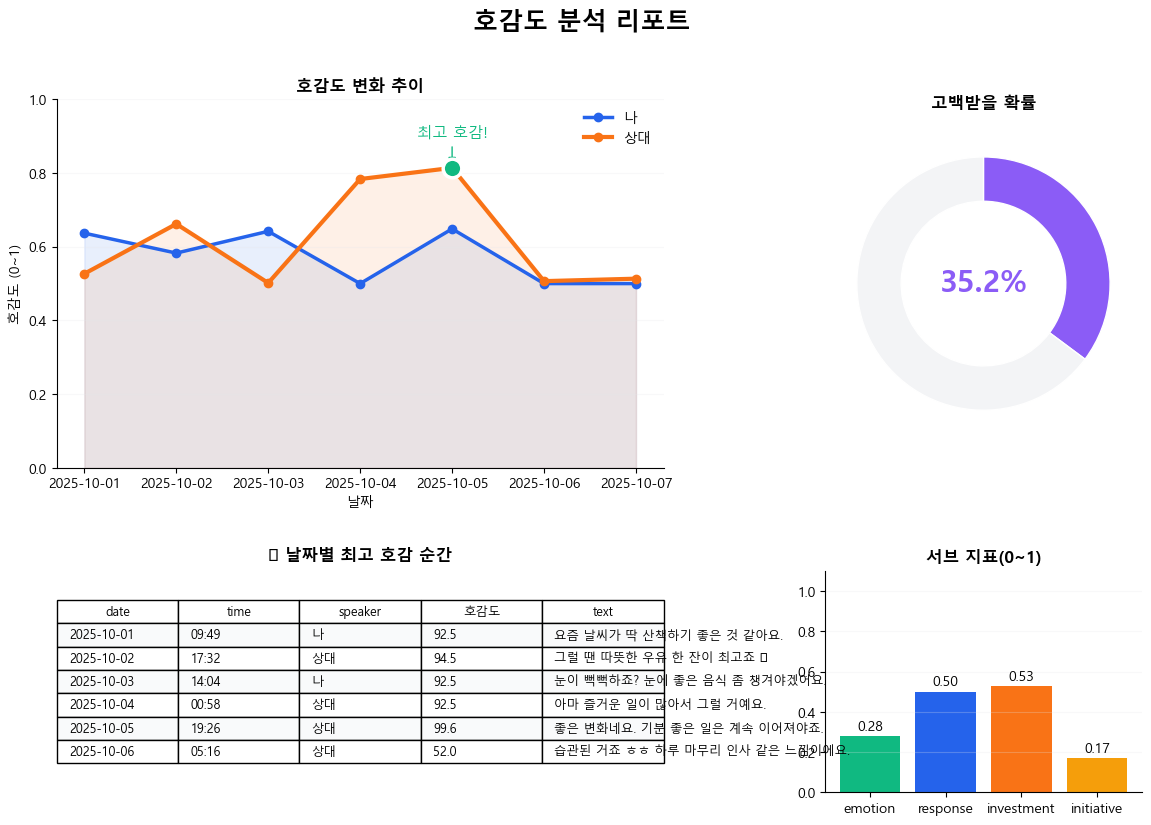

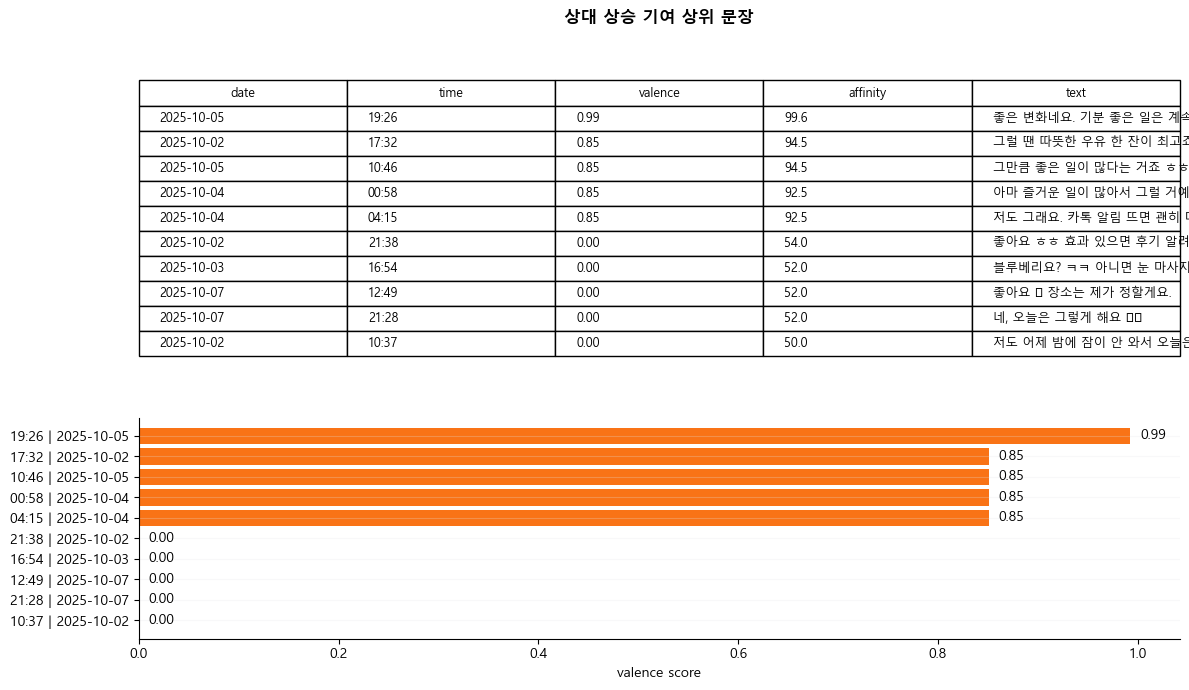

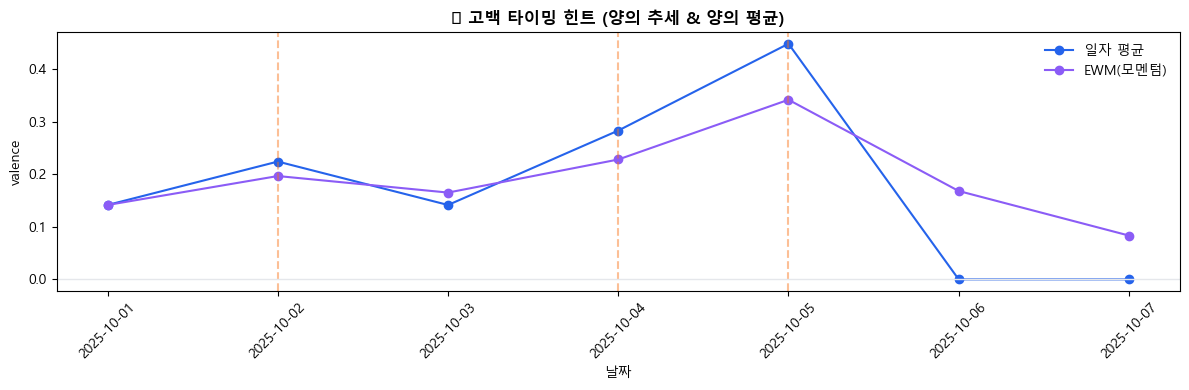

In [ ]:
# =========================================================
# 썸 대화 호감도 종합 리포트 (저장 없이 바로 시각화)
#  - 입력: some.txt (카톡 내보내기 유사 형식), SentiWord_Dict.txt (단어 \t -2..2)
#  - 출력: ① 종합 대시보드 ② 상승 기여 상위 문장 ③ 고백 타이밍 힌트
#  - 핵심 표: 날짜별 최고 호감도 문장 / 일자별 "나 vs 상대" 꺾은선
# =========================================================

import re, os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 경로 설정 (여기만 맞추면 나머지는 자동)
# ---------------------------------------------------------
TXT_PATH = "./some.txt"
LEX_PATH = "./SentiWord_Dict.txt"

assert os.path.exists(TXT_PATH), f"대화 파일 없음: {TXT_PATH}"
assert os.path.exists(LEX_PATH), f"사전 파일 없음: {LEX_PATH}"

# ---------------------------------------------------------
# 공용 팔레트 (보기 좋게)
# ---------------------------------------------------------
PALETTE = {
    "me":      "#2563eb",  # 파랑(나)
    "other":   "#f97316",  # 오렌지(상대)
    "grid":    "#e5e7eb",
    "text":    "#111827",
    "accent":  "#10b981",  # 민트
    "accent2": "#8b5cf6",  # 보라
    "bad":     "#ef4444",
}

def _fmt(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25, color=PALETTE["grid"])

# ---------------------------------------------------------
# 1) 대화 로더 (카톡 유사 포맷)
#    예)
#    2025년 10월 01일 수요일
#    [오전 09:25] 상대: 맞아요. 바람이 살짝 차가워져서 기분이 좋았어요.
# ---------------------------------------------------------
DATE_PAT = re.compile(r"^\s*(\d{4})년\s*(\d{2})월\s*(\d{2})일")
LINE_PAT = re.compile(r"^\s*\[(.*?)\]\s*([^:：]+)\s*[:：]\s*(.*)")
TIME_PAT = re.compile(r"(\d{1,2}):(\d{2})")

def normalize_text(t:str)->str:
    t = re.sub(r"[ㅋㄱ]{2,}", "ㅋㅋ", t)
    t = re.sub(r"[ㅎ]{2,}", "ㅎㅎ", t)
    t = re.sub(r"[ㅠㅜ]{2,}", "ㅠㅠ", t)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def parse_hour_min(timestr:str):
    if not timestr: return (0,0)
    # "오전/오후/점심 14:04" 같은 케이스에서 숫자만 뽑음
    m = TIME_PAT.search(timestr)
    if not m: return (0,0)
    hh = max(0, min(23, int(m.group(1))))
    mm = max(0, min(59, int(m.group(2))))
    return (hh, mm)

def load_dialog(path=TXT_PATH)->pd.DataFrame:
    rows=[]; cur_date=None
    with open(path, encoding="utf-8") as f:
        for i, line in enumerate(f, 1):
            line=line.strip()
            if not line: continue
            dm = DATE_PAT.match(line)
            if dm:
                y, m, d = dm.groups()
                cur_date = f"{y}-{m}-{d}"
                continue
            m = LINE_PAT.match(line)
            if not m or not cur_date:
                continue
            time_str = (m.group(1) or "")
            speaker  = (m.group(2) or "").strip()
            text     = normalize_text((m.group(3) or ""))

            hh, mm = parse_hour_min(time_str)
            ts = pd.to_datetime(f"{cur_date} {hh:02d}:{mm:02d}:00", errors="coerce")

            rows.append({
                "turn": i,
                "date": cur_date,
                "time": f"{hh:02d}:{mm:02d}",
                "timestamp": ts,
                "speaker": speaker,
                "text": text
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("timestamp").reset_index(drop=True)
    print(f"[INFO] 대화 로드: {len(df):,}건")
    return df

# ---------------------------------------------------------
# 2) 감성 사전 로드 (단어 \t 점수[-2..2])
# ---------------------------------------------------------
def load_lexicon(path=LEX_PATH)->dict:
    lex = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if not line or line.startswith("#"): continue
            parts = re.split(r"[\t, ]+", line)
            if len(parts) < 2: continue
            w, s = parts[0], parts[1]
            try:
                score = float(s)
            except:
                continue
            lex[w] = score
    print(f"[INFO] 감성사전 로드: {len(lex):,}개")
    return lex

# ---------------------------------------------------------
# 3) 규칙 기반 확률 추정 (pos/neu/neg) + 호감 점수
# ---------------------------------------------------------
def sentence_probs_with_lex(text: str, lex: dict):
    # 토큰: 단순 공백 분리 + 사전 조회
    toks = re.findall(r"[가-힣A-Za-z0-9]+", text)
    raw = 0.0
    for t in toks:
        if t in lex:
            raw += lex[t]
    # 평활화: 원점 근처는 중립 가중
    # 점수 -> 세 로짓으로 매핑: [neg, neu, pos]
    # 중립 바이어스(=1.0) 넣고 softmax
    neg_logit = -raw
    neu_logit = 1.0 - abs(raw) * 0.5
    pos_logit = raw
    arr = np.array([neg_logit, neu_logit, pos_logit], dtype=np.float32)
    # 안정적 softmax
    arr = arr - arr.max()
    e = np.exp(arr)
    prob = e / e.sum()
    neg, neu, pos = float(prob[0]), float(prob[1]), float(prob[2])
    # 라벨 & 신뢰도
    labs = ["부정","중립","긍정"]
    probs = [neg, neu, pos]
    idx = int(np.argmax(probs))
    return {"pos_prob": pos, "neu_prob": neu, "neg_prob": neg,
            "valence_pred": labs[idx], "valence_conf": probs[idx]}

def compute_affinity(pos: float, neg: float, text: str) -> float:
    # 기본: 50 + 50*(pos-neg), 이모지/긍정단서 가점, 부정표현 감점 (0~100 clip)
    base = 50.0 + 50.0*(pos - neg)
    if re.search(r"(ㅎㅎ|ㅋㅋ|❤️|💓|💖|💗|🥰)", text): base += 2.0
    if re.search(r"(고마워|감사|좋았|좋아|괜찮|최고|행복|힐링)", text): base += 2.0
    if re.search(r"(ㅠ|ㅜ|슬프|힘들|피곤|속상)", text): base -= 1.5
    return float(np.clip(base, 0.0, 100.0))

# ---------------------------------------------------------
# 4) 예측 테이블 생성 (핵심: time 컬럼 포함!)
#    signature 고정: (df, lex, me, other)
# ---------------------------------------------------------
def predict_table(df: pd.DataFrame, lex: dict, me="나", other="상대") -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=[
            "date","time","timestamp","speaker","text",
            "pos_prob","neu_prob","neg_prob","valence_pred","valence_conf","affinity"
        ])
    out = df.copy()
    out["date"] = out["date"].astype(str)
    # time 컬럼이 없을 수 있으므로 안전 보정
    if "time" not in out.columns or out["time"].isna().all():
        out["time"] = out["timestamp"].dt.strftime("%H:%M").fillna("00:00")
    # 확률/라벨
    res = out["text"].apply(lambda t: sentence_probs_with_lex(str(t), lex))
    out["pos_prob"]     = res.apply(lambda d: d["pos_prob"])
    out["neu_prob"]     = res.apply(lambda d: d["neu_prob"])
    out["neg_prob"]     = res.apply(lambda d: d["neg_prob"])
    out["valence_pred"] = res.apply(lambda d: d["valence_pred"])
    out["valence_conf"] = res.apply(lambda d: d["valence_conf"])
    # 호감도
    out["affinity"] = [
        compute_affinity(out.loc[i,"pos_prob"], out.loc[i,"neg_prob"], out.loc[i,"text"])
        for i in range(len(out))
    ]
    # 표준 정렬
    out = out.sort_values(["date","timestamp","turn"]).reset_index(drop=True)
    return out

# ---------------------------------------------------------
# 5) 고백 확률(휴리스틱) + 서브지표
# ---------------------------------------------------------
def confession_probability(df_pred: pd.DataFrame, other="상대"):
    df = df_pred.copy()
    # 상대의 호감 평균, 최근 모멘텀, 상대 발화 비중, 초대/하트 등 키워드
    other_df = df[df["speaker"]==other].copy()
    if other_df.empty:
        return 0.0, {"emotion":0.0, "response":0.0, "investment":0.0, "initiative":0.0}

    # 감정(affinity) — 최근 3일 가중 평균
    other_df["date_dt"] = pd.to_datetime(other_df["date"])
    daily = other_df.groupby("date_dt")["affinity"].mean().reset_index().sort_values("date_dt")
    if len(daily) >= 2:
        momentum = daily["affinity"].ewm(alpha=0.5).mean().diff().iloc[-1]
    else:
        momentum = 0.0
    emotion = float(np.clip((other_df["affinity"].mean()/100.0 + momentum/100.0)/2.0, 0, 1))

    # 응답 속도 대용치(간단): 상대 말의 길이/빈도 — 최근 3일 발화 비율
    day_cnt = df.groupby(["date","speaker"]).size().unstack(fill_value=0)
    speak_ratio = 0.0
    if other in day_cnt.columns:
        recent = day_cnt.tail(3)
        denom = (recent.sum(axis=1)+1e-6)
        speak_ratio = float(np.clip((recent[other]/denom).mean(), 0, 1))

    # 투자도: 상대 평균 문장 길이 정규화
    other_len = other_df["text"].str.len().mean()
    investment = float(np.clip(other_len / 40.0, 0, 1))  # 길수록 투자 ↑ (40자 기준)

    # 주도성: 초대/미래/확답 키워드
    INIT_CUES = r"(같이|함께|보자|갈까|가자|정하자|잡자|통화|저녁|약속|기억할게|좋아요|OK|오케이)"
    initiative = float(np.clip(other_df["text"].str.contains(INIT_CUES).mean()*1.2, 0, 1))

    # 종합(가중)
    prob = 0.40*emotion + 0.20*speak_ratio + 0.20*investment + 0.20*initiative
    prob = float(np.clip(prob, 0, 1))
    details = {"emotion":round(emotion,3),
               "response":round(speak_ratio,3),
               "investment":round(investment,3),
               "initiative":round(initiative,3)}
    return prob, details

# ---------------------------------------------------------
# 6) 예쁜 시각화들
# ---------------------------------------------------------
def plot_dashboard_pretty(df_pred: pd.DataFrame, prob: float, details: dict,
                          me="나", other="상대", title="호감도 분석 리포트"):
    # 날짜별 평균 호감도(나/상대)
    daily = (df_pred.groupby(["date","speaker"])["affinity"]
             .mean().reset_index()
             .pivot(index="date", columns="speaker", values="affinity"))
    dates = daily.index.tolist()

    # 최고 호감일(상대 기준)
    best_other_idx = None
    if (other in daily.columns) and (daily[other].notna().any()):
        best_other_idx = int(np.nanargmax(daily[other].values))

    fig = plt.figure(figsize=(14,9))
    gs = fig.add_gridspec(2, 2, width_ratios=[2.3, 1.2], height_ratios=[2, 1.2],
                          hspace=0.35, wspace=0.35)

    # (좌상) 꺾은선
    ax1 = fig.add_subplot(gs[0,0])
    if (me in daily.columns):
        y_me = daily[me].values/100.0
        ax1.plot(dates, y_me, marker="o", lw=2.5, color=PALETTE["me"], label=me)
        ax1.fill_between(dates, 0, y_me, color=PALETTE["me"], alpha=0.10)
    if (other in daily.columns):
        y_ot = daily[other].values/100.0
        ax1.plot(dates, y_ot, marker="o", lw=3.0, color=PALETTE["other"], label=other, zorder=3)
        ax1.fill_between(dates, 0, y_ot, color=PALETTE["other"], alpha=0.10)
        if best_other_idx is not None and 0 <= best_other_idx < len(dates):
            ax1.scatter([dates[best_other_idx]],[y_ot[best_other_idx]],
                        s=180, edgecolor="white", linewidth=2.5,
                        color=PALETTE["accent"], zorder=5)
            ax1.annotate("최고 호감!",
                         (dates[best_other_idx], y_ot[best_other_idx]),
                         xytext=(0, 22), textcoords="offset points",
                         ha="center", color=PALETTE["accent"], fontsize=11,
                         arrowprops=dict(arrowstyle="-|>", color=PALETTE["accent"]))
    ax1.set_ylim(0, 1.0)
    ax1.set_title("호감도 변화 추이", fontweight="bold")
    ax1.set_xlabel("날짜"); ax1.set_ylabel("호감도 (0~1)")
    _fmt(ax1); ax1.legend(frameon=False)

    # (우상) 도넛 (고백확률)
    ax2 = fig.add_subplot(gs[0,1])
    pct = float(np.clip(prob,0,1))
    wedges, _ = ax2.pie([pct, 1-pct], startangle=90, counterclock=False,
                        colors=[PALETTE["accent2"], "#F3F4F6"],
                        wedgeprops=dict(width=0.35, edgecolor="white"))
    ax2.text(0, 0, f"{pct*100:.1f}%", ha="center", va="center",
             fontsize=22, fontweight="bold", color=PALETTE["accent2"])
    ax2.set_title("고백받을 확률", pad=12, fontweight="bold")

    # (우하) 서브지표 바
    ax3 = fig.add_subplot(gs[1,1])
    labs = list(details.keys()); vals = list(details.values())
    bars = ax3.bar(labs, vals, color=[PALETTE["accent"], PALETTE["me"], PALETTE["other"], "#f59e0b"])
    for b,v in zip(bars, vals):
        ax3.text(b.get_x()+b.get_width()/2, v+0.03, f"{v:.2f}", ha="center", fontsize=10)
    ax3.set_ylim(0, 1.1)
    ax3.set_title("서브 지표(0~1)", fontweight="bold")
    _fmt(ax3)

    # (좌하) 날짜별 최고 호감 문장
    ax4 = fig.add_subplot(gs[1,0]); ax4.axis("off")
    best_tbl = (df_pred
                .loc[df_pred.groupby("date")["affinity"].idxmax(),
                     ["date","time","speaker","affinity","text"]]
                .sort_values("date").reset_index(drop=True))
    best_tbl["affinity"] = best_tbl["affinity"].round(1)
    show = best_tbl.head(6)
    cell_text = [[r["date"], r["time"], r["speaker"], f'{r["affinity"]:.1f}', r["text"]]
                 for _,r in show.iterrows()]
    col_labels = ["date","time","speaker","호감도","text"]
    table = ax4.table(cellText=cell_text, colLabels=col_labels, loc="center",
                      cellLoc="left", colLoc="center")
    table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.4)
    for i in range(1, len(cell_text)+1, 2):
        for j in range(len(col_labels)):
            table[(i, j)].set_facecolor("#f9fafb")
    ax4.set_title("✨ 날짜별 최고 호감 순간", pad=8, fontweight="bold")

    fig.suptitle(title, fontsize=18, fontweight="bold", y=0.98)
    plt.show()

def most_impact_sentences_pretty(df_pred: pd.DataFrame, speaker="상대", topk=10):
    # valence_score: (pos-neg) 없으면 affinity(정규화) 사용
    df = df_pred.copy()
    if {"pos_prob","neg_prob"}.issubset(df.columns):
        df["valence_score"] = df["pos_prob"] - df["neg_prob"]
    else:
        df["valence_score"] = df["affinity"] / 100.0

    daily = (df.groupby(["date","speaker"])["affinity"]
             .mean().reset_index().rename(columns={"affinity":"aff"}))
    dsub = daily[daily["speaker"]==speaker].sort_values("date")
    if dsub.empty:
        print("[INFO] 해당 화자 데이터 없음"); return
    dsub["delta"] = dsub["aff"].diff()

    top_days = (dsub.dropna(subset=["delta"])
                    .sort_values("delta", ascending=False).head(5)["date"].tolist())
    cand = df[(df["speaker"]==speaker) & (df["date"].isin(top_days))]
    if cand.empty:
        print("[INFO] 후보 문장 없음"); return
    top_sent = cand.sort_values(["valence_score","affinity"], ascending=False).head(topk)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), gridspec_kw={"height_ratios":[2,1.2]})
    ax1.axis("off")
    col_labels = ["date","time","valence","affinity","text"]
    cell_text = [[r["date"], r["time"], f'{r["valence_score"]:.2f}', f'{r["affinity"]:.1f}', r["text"]]
                 for _,r in top_sent.iterrows()]
    table = ax1.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="left", colLoc="center")
    table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.25)
    ax1.set_title(f"{speaker} 상승 기여 상위 문장", fontweight="bold", pad=8)

    ax2.barh(top_sent["time"]+" | "+top_sent["date"], top_sent["valence_score"], color=PALETTE["other"])
    for i, v in enumerate(top_sent["valence_score"]):
        ax2.text(v+0.01, i, f"{v:.2f}", va="center")
    ax2.set_xlabel("valence score"); ax2.invert_yaxis(); _fmt(ax2)
    plt.tight_layout(); plt.show()

def plot_timing_hint(df_pred: pd.DataFrame, title="💘 고백 타이밍 힌트 (양의 추세 & 양의 평균)"):
    df = df_pred.copy()
    if {"pos_prob","neg_prob"}.issubset(df.columns):
        df["valence_score"] = df["pos_prob"] - df["neg_prob"]
    else:
        df["valence_score"] = df["affinity"]/100.0

    daily = (df.groupby("date")["valence_score"]
             .mean().reset_index().sort_values("date"))
    daily["ewm"] = daily["valence_score"].ewm(alpha=0.5).mean()
    cands = daily[(daily["valence_score"]>0) & (daily["ewm"].diff()>0)]

    plt.figure(figsize=(12,4))
    plt.plot(daily["date"], daily["valence_score"], marker="o", color=PALETTE["me"], label="일자 평균")
    plt.plot(daily["date"], daily["ewm"], marker="o", color=PALETTE["accent2"], label="EWM(모멘텀)")
    for _, r in cands.iterrows():
        plt.axvline(r["date"], color=PALETTE["other"], ls="--", alpha=0.45)
    plt.axhline(0, color=PALETTE["grid"], lw=1)
    plt.title(title, fontweight="bold"); plt.xlabel("날짜"); plt.ylabel("valence")
    plt.xticks(rotation=45); plt.legend(frameon=False); plt.tight_layout(); plt.show()

# ---------------------------------------------------------
# 7) 메인 실행: 즉시 시각화
# ---------------------------------------------------------
def main():
    df  = load_dialog(TXT_PATH)
    lex = load_lexicon(LEX_PATH)

    # 핵심: predict_table(df, lex, me, other)  ← 시그니처 통일!
    df_pred = predict_table(df, lex, me="나", other="상대")

    # 리포트 숫자 체크
    daily = (df_pred.groupby(["date","speaker"])["affinity"].mean()
             .reset_index().sort_values(["date","speaker"]))
    print("\n[일자별 평균 호감도]")
    try:
        print(daily.pivot(index="date", columns="speaker", values="affinity").round(1).fillna("-"))
    except Exception:
        print(daily)

    # 고백 확률 + 세부지표
    prob, details = confession_probability(df_pred, other="상대")

    # ① 종합 대시보드
    plot_dashboard_pretty(df_pred, prob, details, me="나", other="상대")

    # ② 상승 기여 상위 문장
    most_impact_sentences_pretty(df_pred, speaker="상대", topk=10)

    # ③ 고백 타이밍 힌트
    plot_timing_hint(df_pred)

if __name__ == "__main__":
    main()
